# Exploratory Data Analysis

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
import warnings
warnings.filterwarnings('ignore')

In [47]:
df = pd.read_csv('SCMS_Delivery_History_Dataset.csv')

In [48]:
df.shape

(10324, 33)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [50]:
df.select_dtypes(include=['int','float']).columns

Index(['ID', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price',
       'Line Item Insurance (USD)'],
      dtype='object')

In [51]:
df.select_dtypes(include=['object']).columns

Index(['Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Manufacturing Site', 'First Line Designation',
       'Weight (Kilograms)', 'Freight Cost (USD)'],
      dtype='object')

## Missing Values

In [52]:
df.isnull().sum().sort_values(ascending=False).head()

Dosage                       1736
Shipment Mode                 360
Line Item Insurance (USD)     287
Molecule/Test Type              0
Brand                           0
dtype: int64

## Duplicate Values

In [53]:
df.duplicated().sum()

0

## Data Cleansing

In [54]:
def data_cleanup(df):

    df['Weight (Kilograms)'] = df['Weight (Kilograms)'].astype(str).str.extract(r'(\d+\.?\d*)')
    df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'])

    df['Freight Cost (USD)'] = df['Freight Cost (USD)'].astype(str).str.extract(r'(\d+\.?\d*)')
    df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'])

    df['Weight (Kilograms)'] = df['Weight (Kilograms)'].fillna(df['Weight (Kilograms)'].mean())
    df['Freight Cost (USD)'] = df['Freight Cost (USD)'].fillna(df['Freight Cost (USD)'].mean())

    return df

In [55]:
df = data_cleanup(df)

## Data Distribution

In [56]:
df.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,4004.061245,9522.285944,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,11377.282789,13083.572182,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.750000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,490.000000,2229.730000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,2234.000000,5924.610000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,4004.061245,9648.980000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,857354.000000,289653.200000,7708.440000


In [57]:
df.select_dtypes(include=['int','float']).columns

Index(['ID', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Weight (Kilograms)',
       'Freight Cost (USD)', 'Line Item Insurance (USD)'],
      dtype='object')

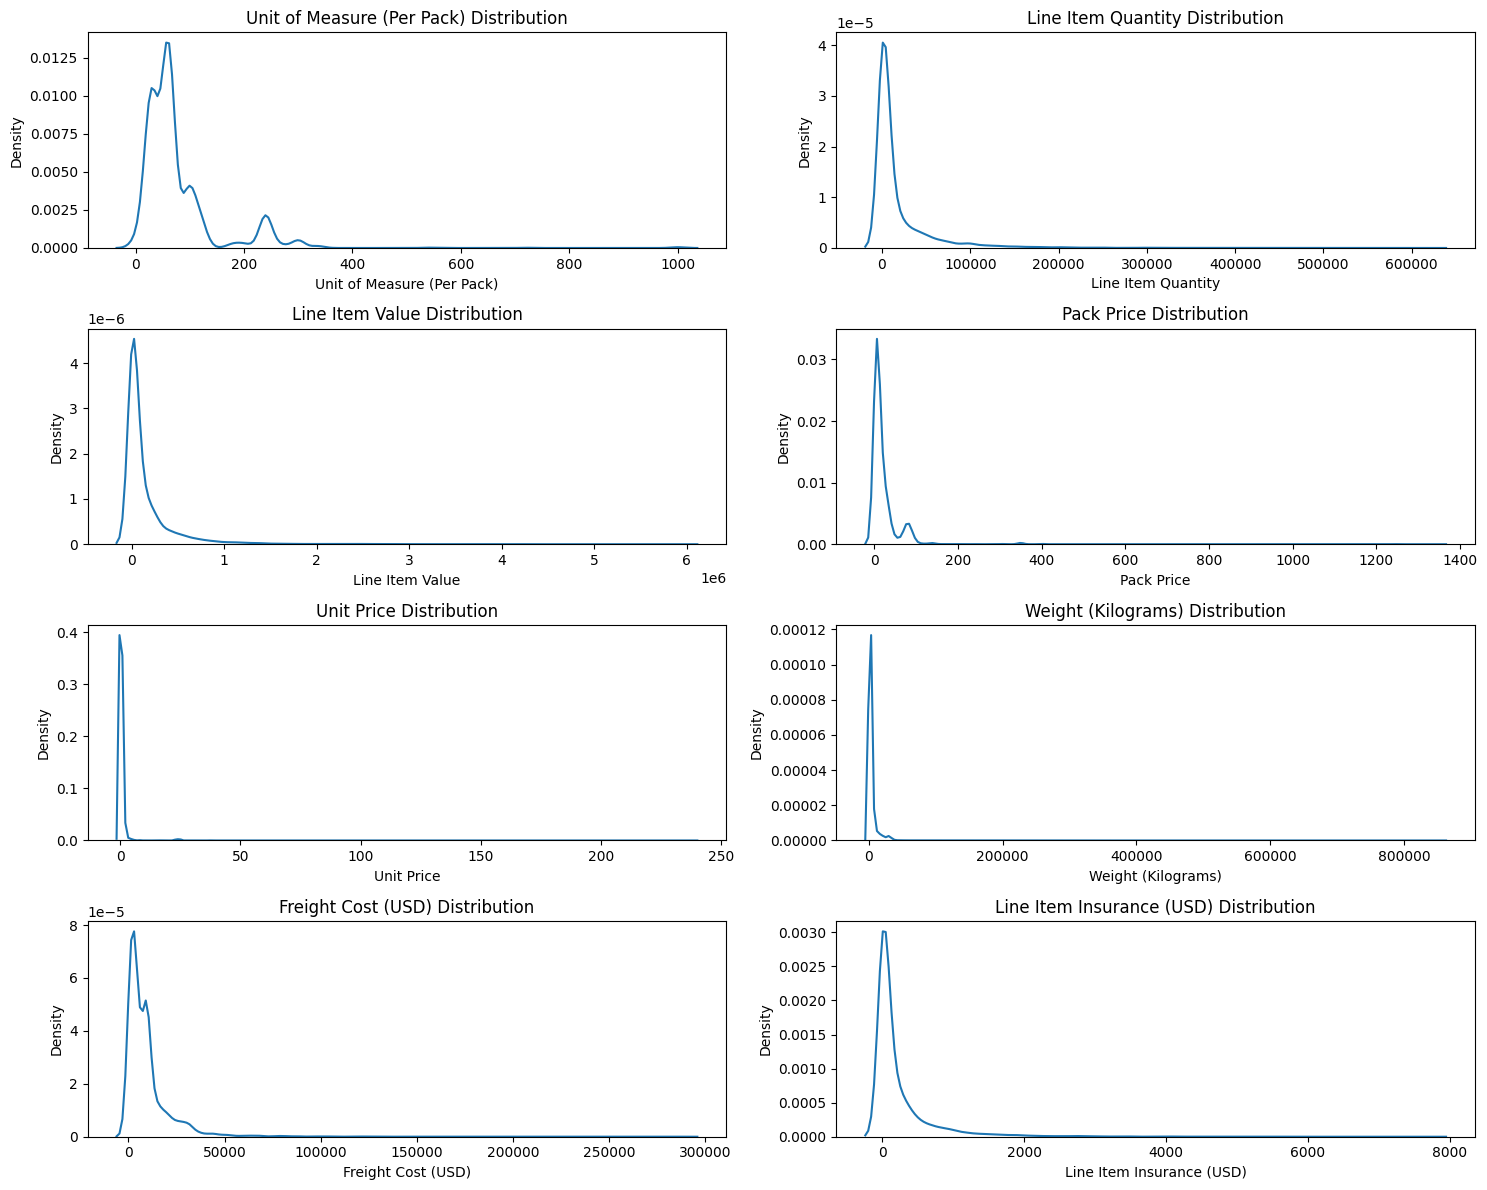

In [58]:
fig, axes = plt.subplots(4, 2, figsize=(15, 12))

axes = axes.flatten()

for i, c in enumerate(df[['Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Weight (Kilograms)','Freight Cost (USD)','Line Item Insurance (USD)']]):
    sns.kdeplot(data=df, x=c, ax=axes[i])
    axes[i].set_xlabel(c)
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{c} Distribution')

plt.tight_layout()
plt.show()

## Correlation

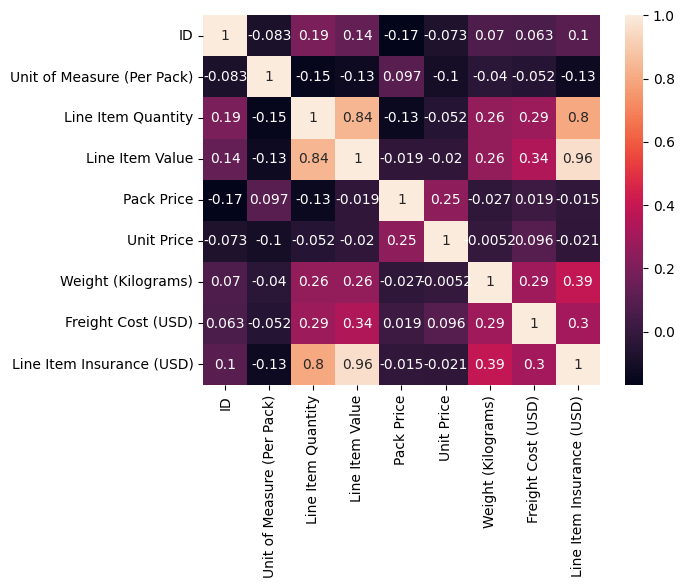

In [59]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

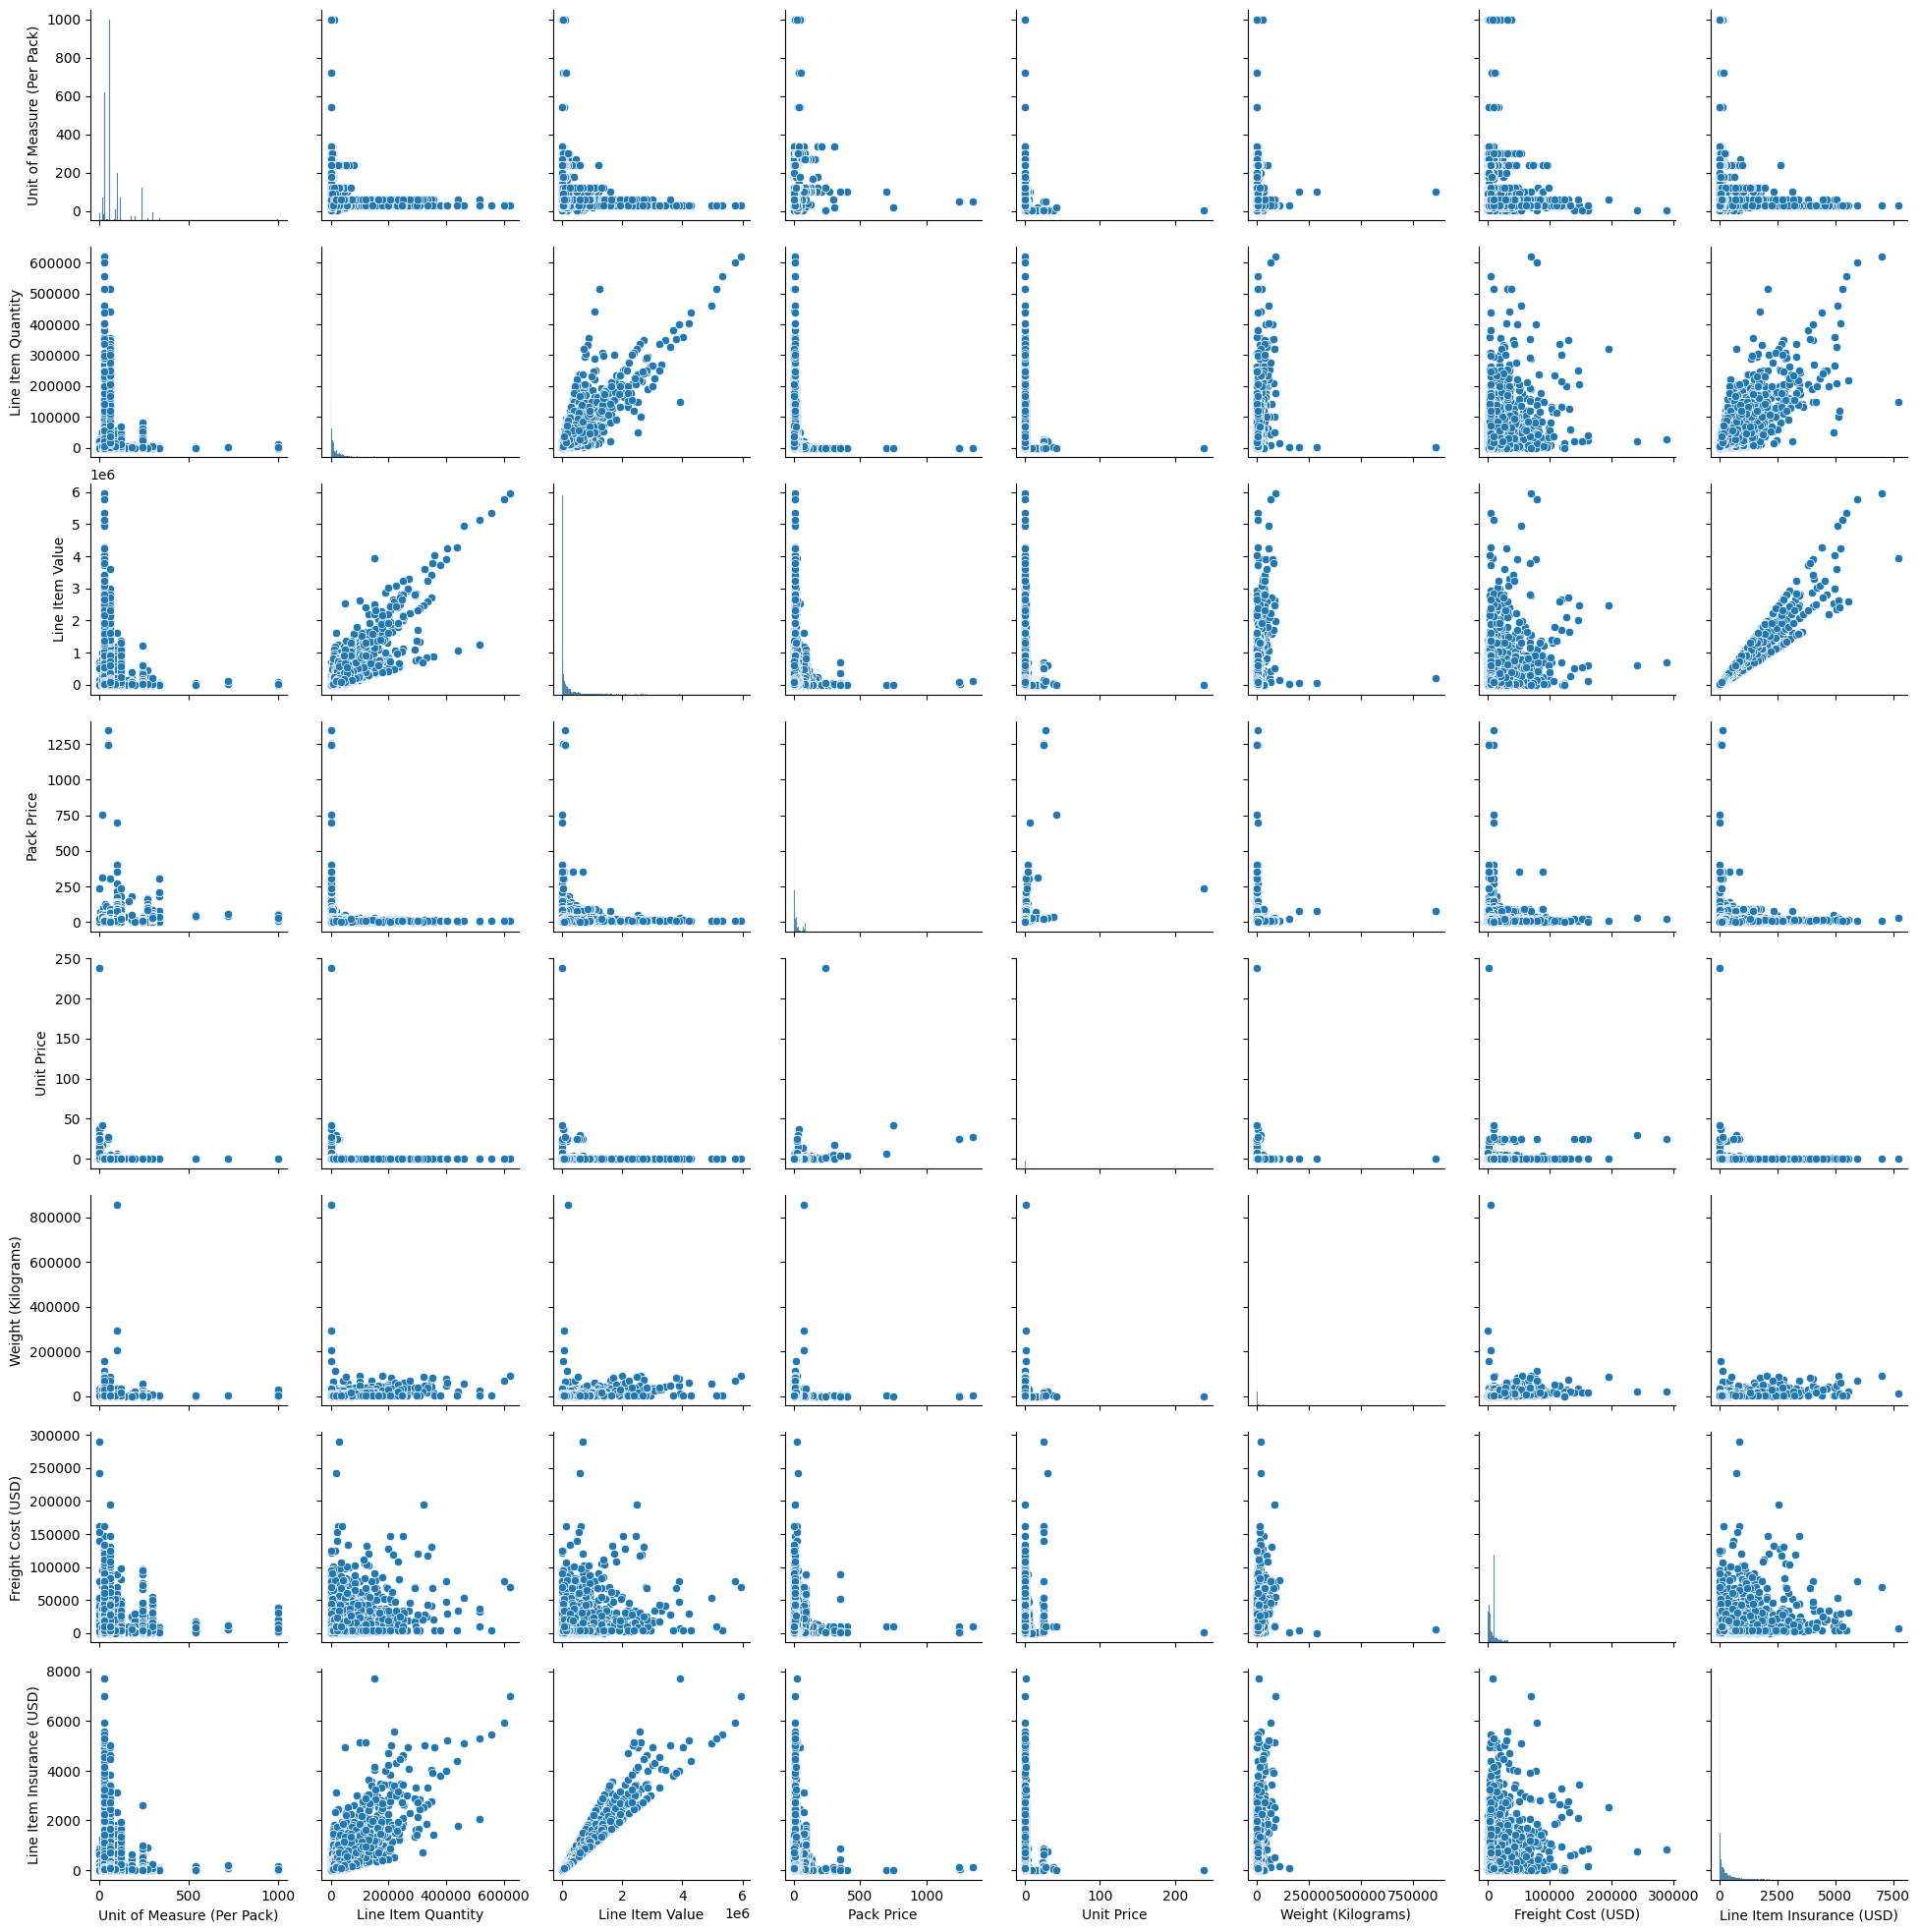

In [60]:
sns.pairplot(df[['Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Weight (Kilograms)','Freight Cost (USD)','Line Item Insurance (USD)']])
plt.show()

## Outlier

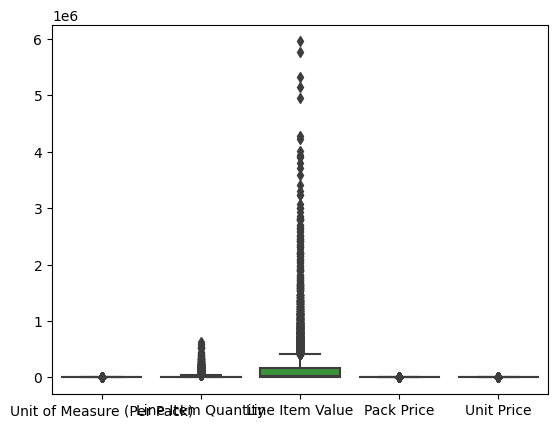

In [61]:
sns.boxplot(df[['Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price']])
plt.show()

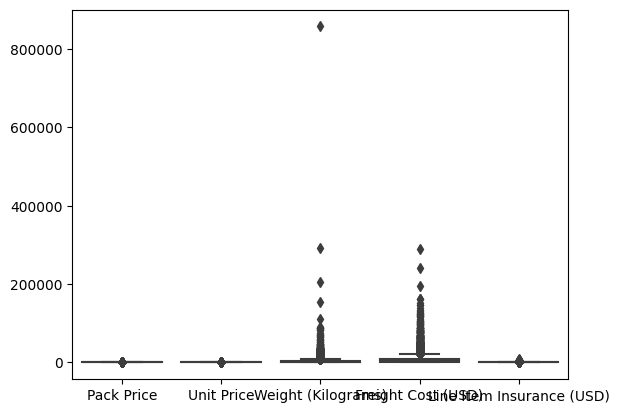

In [62]:
sns.boxplot(df[['Pack Price', 'Unit Price', 'Weight (Kilograms)','Freight Cost (USD)','Line Item Insurance (USD)']])
plt.show()

## Categorical Features

In [72]:
cat_cols = df.select_dtypes(include=['object']).columns

selected_cols = [col for col in cat_cols if col in [
    'Country','Shipment Mode','Product Group'
]]

df_cat = df[selected_cols]

df_cat.head()

,Country,Shipment Mode,Product Group
0,Côte d'Ivoire,Air,HRDT
1,Vietnam,Air,ARV
2,Côte d'Ivoire,Air,HRDT
3,Vietnam,Air,ARV
4,Vietnam,Air,ARV


### Univarient Analysis

In [ ]:
for col in df_cat.columns:
    print(f'\nColumn: {col}')
    print(df_cat[col].value_counts(normalize=True) * 100)


Column: Country
South Africa          13.618752
Nigeria               11.565285
Côte d'Ivoire         10.490120
Uganda                 7.545525
Vietnam                6.664084
Zambia                 6.615653
Haiti                  6.344440
Mozambique             6.111972
Zimbabwe               5.211158
Tanzania               5.027121
Rwanda                 4.165052
Congo, DRC             3.225494
Guyana                 2.295622
Ethiopia               2.092212
South Sudan            1.588532
Kenya                  1.075165
Burundi                0.949244
Namibia                0.920186
Cameroon               0.726463
Botswana               0.678032
Ghana                  0.561798
Dominican Republic     0.503681
Sudan                  0.445564
Swaziland              0.339016
Mali                   0.164665
Guatemala              0.145293
Pakistan               0.145293
Malawi                 0.135606
Benin                  0.125920
Lebanon                0.077489
Libya                  

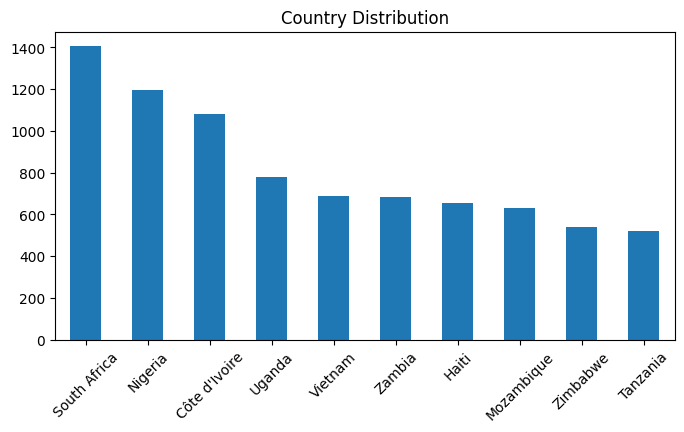

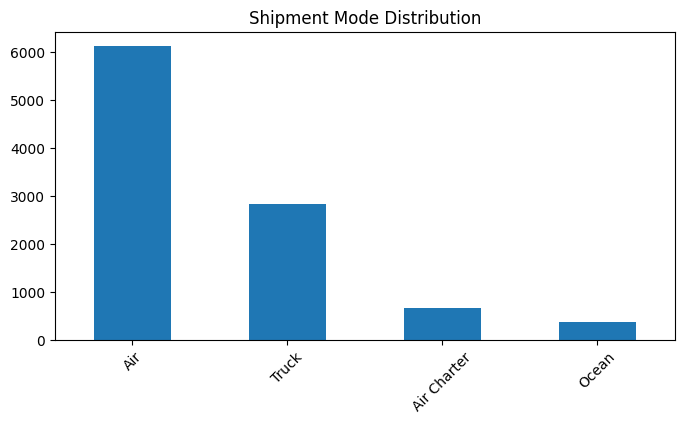

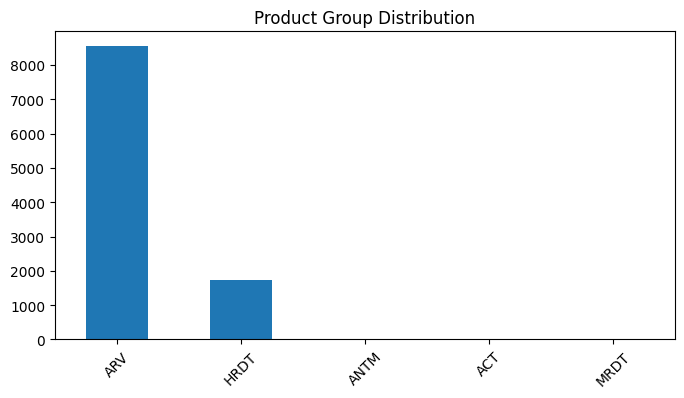

In [ ]:
for col in df_cat.columns:
    df_cat[col].value_counts().head(10).plot(kind='bar', figsize=(8,4))
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show()

### Bivariate Analysis

In [93]:
df_cat.columns

Index(['Country', 'Shipment Mode', 'Product Group'], dtype='object')

In [97]:
df.groupby(['Country']).agg(Avg_Insurance=('Line Item Insurance (USD)','mean'),
                            Min_Insurance=('Line Item Insurance (USD)','min'),
                            Max_Insurance=('Line Item Insurance (USD)','max'),
                            Total_Insurance=('Line Item Insurance (USD)','sum')).reset_index().sort_values(by='Avg_Insurance',ascending=False).head(10)

,Country,Avg_Insurance,Min_Insurance,Max_Insurance,Total_Insurance
41,Zambia,576.250282,0.01,5930.22,367647.68
18,Kenya,542.996847,0.00,3136.00,60272.65
24,Malawi,517.694286,0.59,3465.16,7247.72
28,Nigeria,440.726618,0.00,7708.44,509479.97
26,Mozambique,413.107960,0.00,7005.49,244973.02
37,Tanzania,384.232795,0.00,4939.20,195190.26
36,Swaziland,283.200000,0.20,2263.68,9912.00
42,Zimbabwe,272.648558,0.00,4965.32,143685.79
30,Rwanda,261.115379,0.00,3487.13,106796.19
7,Cameroon,249.431200,0.31,2050.06,18707.34


In [101]:
df.groupby(['Shipment Mode']).agg(Avg_Insurance=('Line Item Insurance (USD)','mean'),
                            Min_Insurance=('Line Item Insurance (USD)','min'),
                            Max_Insurance=('Line Item Insurance (USD)','max'),
                            Total_Insurance=('Line Item Insurance (USD)','sum')).reset_index().sort_values(by='Avg_Insurance',ascending=False)

,Shipment Mode,Avg_Insurance,Min_Insurance,Max_Insurance,Total_Insurance
2,Ocean,567.808518,0.46,3487.13,210656.96
1,Air Charter,543.556585,0.01,7708.44,353311.78
3,Truck,294.259442,0.00,7005.49,832754.22
0,Air,162.401546,0.00,4939.20,963365.97


In [102]:
df.groupby(['Product Group']).agg(Avg_Insurance=('Line Item Insurance (USD)','mean'),
                            Min_Insurance=('Line Item Insurance (USD)','min'),
                            Max_Insurance=('Line Item Insurance (USD)','max'),
                            Total_Insurance=('Line Item Insurance (USD)','sum')).reset_index().sort_values(by='Avg_Insurance',ascending=False)

,Product Group,Avg_Insurance,Min_Insurance,Max_Insurance,Total_Insurance
2,ARV,251.374713,0.00,7708.44,2096716.48
3,HRDT,188.954224,0.00,3136.00,311774.47
0,ACT,68.250000,1.40,185.06,1092.00
1,ANTM,16.072727,0.30,140.96,353.60
4,MRDT,15.507500,0.06,70.83,124.06


## Final Data

In [112]:
df[['Shipment Mode','Pack Price','Line Item Quantity','Weight (Kilograms)', 'Freight Cost (USD)','Line Item Insurance (USD)']].head()

,Shipment Mode,Pack Price,Line Item Quantity,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,Air,29.00,19,13.0,780.34,NaN
1,Air,6.20,1000,358.0,4521.50,NaN
2,Air,80.00,500,171.0,1653.78,NaN
3,Air,3.99,31920,1855.0,16007.06,NaN
4,Air,3.20,38000,7590.0,45450.08,NaN


In [113]:
final_df = df[['Shipment Mode','Pack Price','Line Item Quantity','Weight (Kilograms)', 'Freight Cost (USD)','Line Item Insurance (USD)']]

In [114]:
final_df.to_csv('final_df.csv',index=False)